# Experiment 9: Comparative Analysis of Statistical & Predictive Models on Diabetes Datasets

**AIM:**  
To compare univariate descriptive statistics and predictive regression models (Linear Regression vs. Logistic Regression) between the UCI Diabetes Dataset and the Pima Indians Diabetes Dataset.

**SOFTWARE REQUIREMENTS:**  
- **Python**: Version 3.13.x  
- **Jupyter Notebook**: Version 7.x  
- **Packages**: NumPy, Pandas, Scikit-Learn, Matplotlib, Seaborn  

---
### THEORY:
- **Comparative Data Analytics**: Systematically evaluating distributional parameters across diverse data cohorts to identify sample bias, variance discrepancies, and domain shift.
- **Statistical Benchmarking**: Comparing central tendency (mean, median), spread (std, IQR), and model evaluation metrics ($R^2$ score for continuous regression; classification accuracy for binary outcome prediction).

---
### PROCEDURE:
1. Load both the UCI Diabetes and Pima Indians Diabetes datasets.
2. Compute full summary descriptive statistics (`.describe().T`) on numerical features for both datasets.
3. Fit a Linear Regression model (`Glucose` $\rightarrow$ `BMI`) on both datasets and compute $R^2$ scores.
4. Fit a Logistic Regression model on multivariate health features (`Glucose`, `BloodPressure`, `BMI`, `Age` $\rightarrow$ `Outcome`) and compute test set classification accuracy.
5. Generate comparative visualizations and summarize insights.

## 1. Import Libraries & Load Datasets

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, accuracy_score

uci_diabetes = pd.read_csv('uci_diabetes.csv')
pima_columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
pima_diabetes = pd.read_csv('pima_diabetes.csv', header=None, names=pima_columns)
print('Libraries imported successfully!')
print('Datasets loaded successfully!')

Libraries imported successfully!
Datasets loaded successfully!


## 2. Univariate Statistical Distribution Comparison

In [2]:
numerical_columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

uci_stats = uci_diabetes[numerical_columns].describe().T
pima_stats = pima_diabetes[numerical_columns].describe().T

print('UCI Diabetes Dataset Statistics:')
print(uci_stats[['count', 'mean', 'std', 'min', '50%', 'max']])
print('\nPima Indians Diabetes Dataset Statistics:')
print(pima_stats[['count', 'mean', 'std', 'min', '50%', 'max']])

UCI Diabetes Dataset Statistics:
                          count       mean  ...       50%     max
Glucose                   100.0  119.95000  ...  111.0000  197.00
BloodPressure             100.0   67.71000  ...   72.0000  108.00
SkinThickness             100.0   21.41000  ...   26.0000   99.00
Insulin                   100.0   76.24000  ...    0.0000  579.00
BMI                       100.0   32.40100  ...   32.6500   53.20
DiabetesPedigreeFunction  100.0    0.45654  ...    0.3675    1.39
Age                       100.0   36.12000  ...   31.5000   67.00

[7 rows x 6 columns]

Pima Indians Diabetes Dataset Statistics:
                          count        mean  ...       50%     max
Glucose                   768.0  120.894531  ...  117.0000  199.00
BloodPressure             768.0   69.105469  ...   72.0000  122.00
SkinThickness             768.0   20.536458  ...   23.0000   99.00
Insulin                   768.0   79.799479  ...   30.5000  846.00
BMI                       768.0   31.99

## 3. Regression & Classification Performance Benchmark

Linear Regression R2 Scores:
UCI Diabetes: 0.1358
Pima Indians: 0.0489

Logistic Regression Accuracy:
UCI Diabetes: 0.7500
Pima Indians: 0.7403


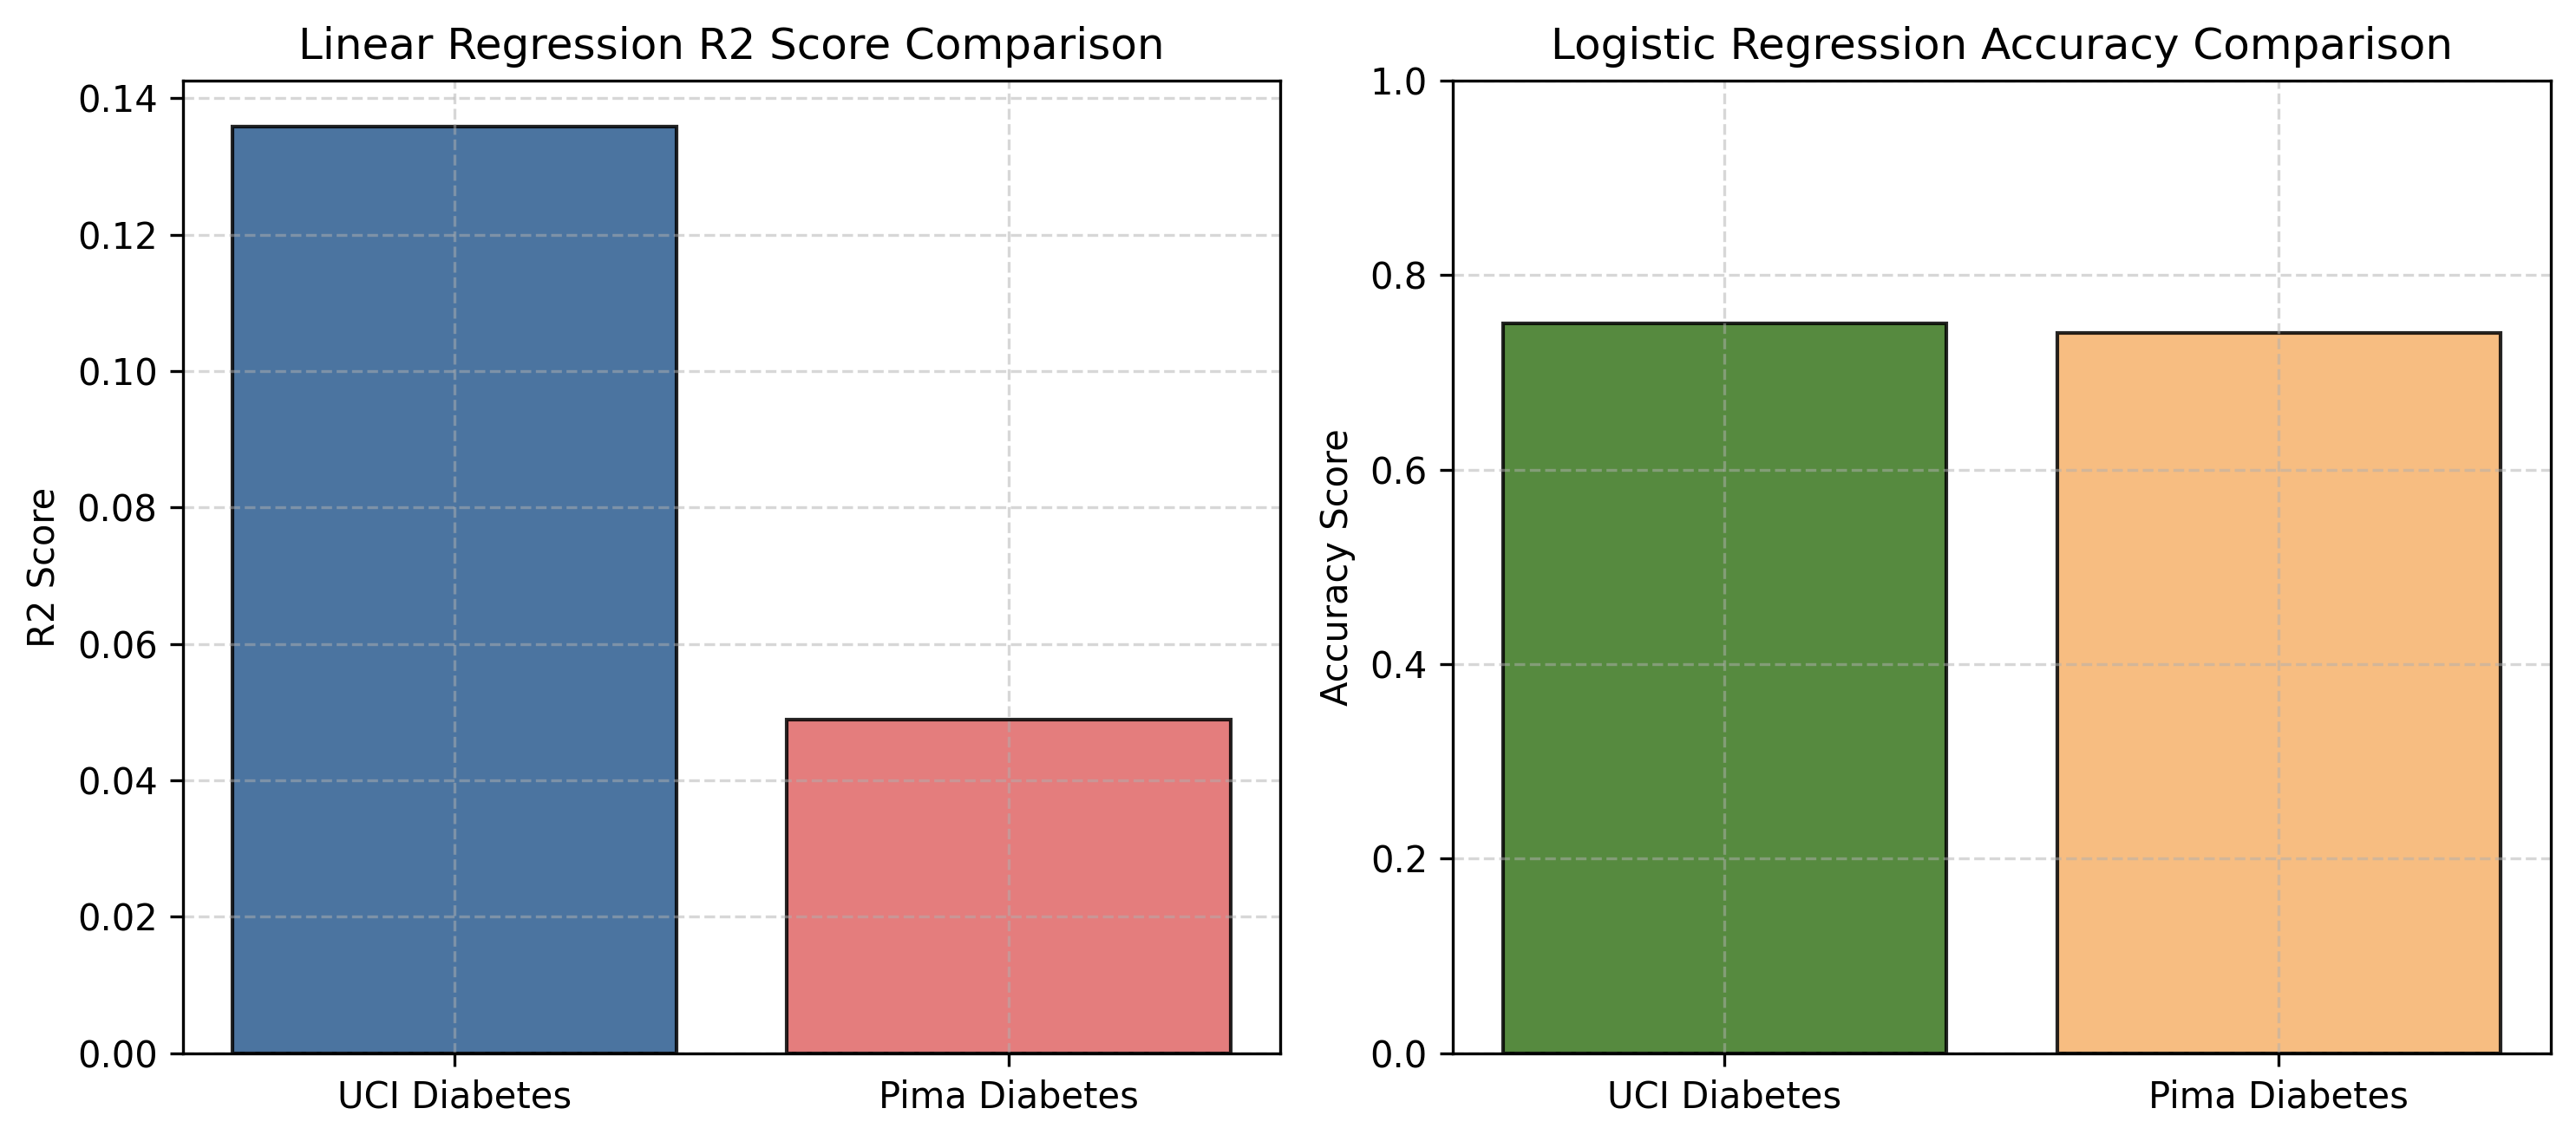

In [3]:
def get_linear_r2(df):
    X = df[['Glucose']]
    y = df['BMI']
    model = LinearRegression().fit(X, y)
    return r2_score(y, model.predict(X))

def get_logistic_accuracy(df):
    features = ['Glucose', 'BloodPressure', 'BMI', 'Age']
    X = df[features]
    y = df['Outcome']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = LogisticRegression(max_iter=1000).fit(X_train, y_train)
    return accuracy_score(y_test, model.predict(X_test))

uci_r2 = get_linear_r2(uci_diabetes)
pima_r2 = get_linear_r2(pima_diabetes)
uci_accuracy = get_logistic_accuracy(uci_diabetes)
pima_accuracy = get_logistic_accuracy(pima_diabetes)

print('Linear Regression R2 Scores:')
print(f'UCI Diabetes: {uci_r2:.4f}')
print(f'Pima Indians: {pima_r2:.4f}')
print('\nLogistic Regression Accuracy:')
print(f'UCI Diabetes: {uci_accuracy:.4f}')
print(f'Pima Indians: {pima_accuracy:.4f}')

fig, ax = plt.subplots(1, 2, figsize=(10, 4.5))
models = ['UCI Diabetes', 'Pima Diabetes']
ax[0].bar(models, [uci_r2, pima_r2], color=['#2b5c8f', '#e06666'], edgecolor='k', alpha=0.85)
ax[0].set_title('Linear Regression R2 Score Comparison')
ax[0].set_ylabel('R2 Score')
ax[0].grid(True, linestyle='--', alpha=0.5)

ax[1].bar(models, [uci_accuracy, pima_accuracy], color=['#38761d', '#f6b26b'], edgecolor='k', alpha=0.85)
ax[1].set_title('Logistic Regression Accuracy Comparison')
ax[1].set_ylabel('Accuracy Score')
ax[1].set_ylim(0, 1)
ax[1].grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()